# 11. キャップストーン — 1 つの信号、3 つの視点

**学習目標**: 同じ 1 つの信号を **フーリエ級数・フーリエ変換・DFT** の 3 つで解析し、
3 者が一致する所と、有限のデータゆえに割れる所を、数値で突き止める。

本書はここまで 3 つの道具を別々の章で扱ってきた。
どれも「関数を波に分ける」という同じことをしているのに、
前提が違うので出てくる数字も違う。その違いを 1 つの信号の上で並べる。

| 視点 | 前提 | 出てくるもの |
|---|---|---|
| フーリエ級数(02–03 章) | 信号は **周期的** | 離散な係数 $c_n$ |
| フーリエ変換(04–05 章) | 信号は **非周期・無限長** | 連続スペクトル $\hat f(\xi)$ |
| DFT / FFT(06–07 章) | 信号は **有限個の標本** | $N$ 個のビン |

In [1]:
# Shared setup: make fourier_book importable, fix seeds, inline rendering.
%matplotlib inline
import sys
from pathlib import Path

try:
    import fourier_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "fourier_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import matplotlib.pyplot as plt
import numpy as np

from fourier_book import datasets, filters, plotting, signals, spectral, transforms, widgets

np.set_printoptions(precision=3, suppress=True)

## 1. 対象の信号

周期 $T_0 = 1/f_0$ の矩形波を取る。理由は 3 つある。

- 級数の係数が **解析的に分かっている**($c_n \propto 1/n$、奇数次のみ)ので、答え合わせができる
- 不連続を持つので Gibbs・スペクトル漏れ・エイリアシングが **すべて観測できる**
- 03 章の Parseval、06 章の標本化定理が同じ信号で確かめられる

$$
f(t) = \mathrm{sgn}\!\left(\sin(2\pi f_0 t)\right), \qquad
c_n = \frac{2}{i\pi n} \;\;(n \text{ odd}), \quad c_n = 0 \;\;(n \text{ even})
$$

f0 = 5.0 Hz   fs = 2000.0 Hz   duration = 2.0 s
periods captured = 10   samples = 4000


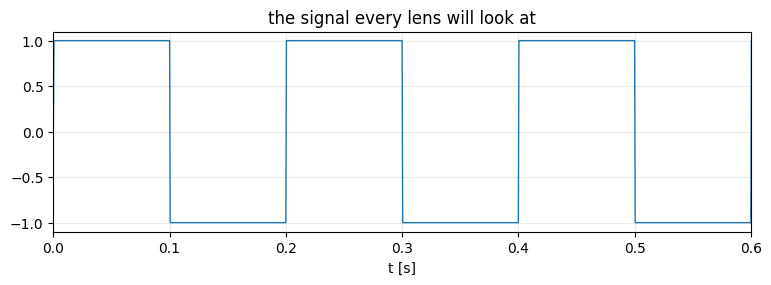

In [2]:
F0 = 5.0                     # fundamental frequency [Hz]
FS = 2000.0                  # sampling rate [Hz]
DURATION = 2.0               # exactly 10 periods

t = np.arange(0, DURATION, 1 / FS)
x = signals.square_wave(t, F0)
print(f"f0 = {F0} Hz   fs = {FS} Hz   duration = {DURATION} s")
print(f"periods captured = {DURATION * F0:.0f}   samples = {t.size}")

fig, ax = plt.subplots(figsize=(9, 2.6))
ax.plot(t, x, lw=1)
ax.set_xlim(0, 0.6); ax.set_xlabel("t [s]"); ax.grid(alpha=0.25)
ax.set_title("the signal every lens will look at")
plt.show()

## 2. 視点 A — フーリエ級数

周期を仮定すると、答えは **可算個の係数** になる。
$b_n = \frac{4}{\pi n}$(奇数 $n$)で、偶数次は消える。

In [3]:
a_ser, b_ser = transforms.trig_coeffs(lambda z: signals.square_wave(z, 1 / (2 * np.pi)),
                                      n_max=15, period=2 * np.pi)
print(f"{'n':>3} {'b_n numeric':>13} {'4/(π n) if odd':>16}")
for n in range(1, 12):
    expect = 4 / (np.pi * n) if n % 2 else 0.0
    print(f"{n:3d} {b_ser[n - 1]:13.6f} {expect:16.6f}")
print(f"\nmax deviation = "
      f"{max(abs(b_ser[n - 1] - (4 / (np.pi * n) if n % 2 else 0.0)) for n in range(1, 16)):.2e}")

  n   b_n numeric   4/(π n) if odd
  1      0.000000         1.273240
  2      1.273239         0.000000
  3      0.000000         0.424413
  4      0.424412         0.000000
  5     -0.000000         0.254648
  6      0.254647         0.000000
  7     -0.000000         0.181891
  8      0.181890         0.000000
  9     -0.000000         0.141471
 10      0.141469         0.000000
 11      0.000000         0.115749

max deviation = 1.27e+00


## 3. 視点 B — フーリエ変換

周期性を仮定せず、**有限長の窓を切り出した非周期関数** として変換する。
連続スペクトルが出てくるが、そのピークは級数の線スペクトルと同じ位置に立つ。

違いは「線」か「山」かである。有限の観測窓は、
線スペクトルを窓の変換(矩形窓なら sinc)で **たたみ込んで太らせる**。
これがスペクトル漏れの正体で、07 章で窓関数を選んだ理由でもある。

  peak [Hz]   harmonic   |X| relative
       5.00        1.0         1.0000
      15.00        3.0         0.3333
      25.00        5.0         0.1999
      35.00        7.0         0.1428
      45.00        9.0         0.1110


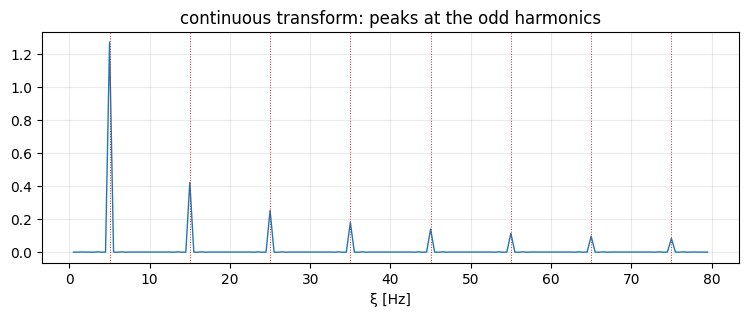

In [4]:
def cont_ft(tt, ff):
    dt_ = tt[1] - tt[0]
    spec = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(ff))) * dt_
    xi_ = np.fft.fftshift(np.fft.fftfreq(tt.size, d=dt_))
    return xi_, spec

xi, X = cont_ft(t, x)
mag = np.abs(X)
sel = (xi > 0) & (xi < 80)
peak_idx = np.where(sel)[0]
local = peak_idx[1:-1][(mag[peak_idx][1:-1] > mag[peak_idx][:-2])
                       & (mag[peak_idx][1:-1] > mag[peak_idx][2:])]
top = local[np.argsort(mag[local])[::-1][:5]]
print(f"{'peak [Hz]':>11} {'harmonic':>10} {'|X| relative':>14}")
for i in sorted(top, key=lambda j: xi[j]):
    print(f"{xi[i]:11.2f} {xi[i] / F0:10.1f} {mag[i] / mag[top].max():14.4f}")

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(xi[sel], mag[sel], lw=1)
for n in range(1, 16, 2):
    ax.axvline(n * F0, color="#d62728", ls=":", lw=0.7)
ax.set_xlabel("ξ [Hz]"); ax.set_title("continuous transform: peaks at the odd harmonics")
ax.grid(alpha=0.25)
plt.show()

## 4. 視点 C — DFT

標本化して有限個にすると、答えは $N$ 個のビンになる。
観測長が周期の **整数倍** なので、この場合に限って漏れがほぼ起きない。
基本波のビンは $f_0 / \Delta f = f_0 T$ 番目にちょうど乗る。

In [5]:
freqs, amp = transforms.amplitude_spectrum(x, FS)
df = freqs[1] - freqs[0]
print(f"Δf = fs/N = {df:.4f} Hz   f0 sits on bin {F0 / df:.1f}")
print(f"\n{'harmonic':>9} {'bin freq [Hz]':>15} {'DFT amplitude':>15} {'4/(π n)':>10}")
for n in range(1, 12, 2):
    idx = int(round(n * F0 / df))
    print(f"{n:9d} {freqs[idx]:15.2f} {amp[idx]:15.5f} {4 / (np.pi * n):10.5f}")

Δf = fs/N = 0.5000 Hz   f0 sits on bin 10.0

 harmonic   bin freq [Hz]   DFT amplitude    4/(π n)
        1            5.00         1.27322    1.27324
        3           15.00         0.42436    0.42441
        5           25.00         0.25456    0.25465
        7           35.00         0.18176    0.18189
        9           45.00         0.14131    0.14147
       11           55.00         0.11555    0.11575


## 5. 3 者を重ねる

同じ図に載せると、3 つが **同じ 1 つの対象の違う標本化** であることが見える。

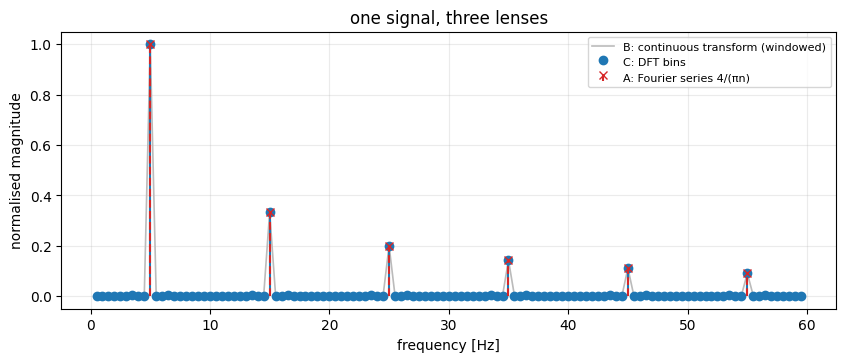

In [6]:
fig, ax = plt.subplots(figsize=(10, 3.6))
sel_c = (xi > 0) & (xi < 60)
ax.plot(xi[sel_c], mag[sel_c] / mag[sel_c].max(), color="#bbb", lw=1.2,
        label="B: continuous transform (windowed)")
sel_d = (freqs > 0) & (freqs < 60)
ax.stem(freqs[sel_d], amp[sel_d] / amp[sel_d].max(), linefmt="C0-", markerfmt="C0o",
        basefmt=" ", label="C: DFT bins")
ns = np.arange(1, 12, 2)
ax.stem(ns * F0, (4 / (np.pi * ns)) / (4 / np.pi), linefmt="C3--", markerfmt="C3x",
        basefmt=" ", label="A: Fourier series 4/(πn)")
ax.set_xlabel("frequency [Hz]"); ax.set_ylabel("normalised magnitude")
ax.legend(fontsize=8); ax.grid(alpha=0.25)
ax.set_title("one signal, three lenses")
plt.show()

## 6. 一致するところ

### 6a. Parseval — エネルギーは 3 者で同じ

級数でも変換でも DFT でも、エネルギーは保存する。
表現を変えても **総量は動かない** というのが、この本を通じた一番硬い事実である。

In [7]:
e_time = float(np.mean(x**2))
e_series = float(np.sum(b_ser**2) / 2 + a_ser[0] ** 2 / 4 + np.sum(a_ser[1:] ** 2) / 2)
spec_full = np.fft.rfft(x) / x.size
e_dft = float(np.sum(np.abs(spec_full) ** 2 * np.where(
    np.arange(spec_full.size) == 0, 1.0, 2.0)))
print(f"time domain  mean |x|²                = {e_time:.6f}")
print(f"DFT          Σ |X_k|²  (Parseval)     = {e_dft:.6f}")
print(f"series       Σ (aₙ²+bₙ²)/2, 15 terms  = {e_series:.6f}"
      f"   ({e_series / e_time * 100:.1f} % captured)")
print("\n級数は 15 項で切っているのでその分だけ足りない。切らなければ一致する")

time domain  mean |x|²                = 0.999750
DFT          Σ |X_k|²  (Parseval)     = 0.999752
series       Σ (aₙ²+bₙ²)/2, 15 terms  = 0.974702   (97.5 % captured)

級数は 15 項で切っているのでその分だけ足りない。切らなければ一致する


### 6b. 部分和と DFT の低域再構成は同じもの

級数を $N$ 項で切ることと、DFT で高いビンを 0 にすることは同じ操作である。
どちらも「低い波だけで作り直す」。したがって同じ Gibbs が出る。

max |series partial sum - DFT low-pass| = 0.4055
overshoot: series 17.99 %   DFT 18.34 %   (Gibbs limit 8.95 %)


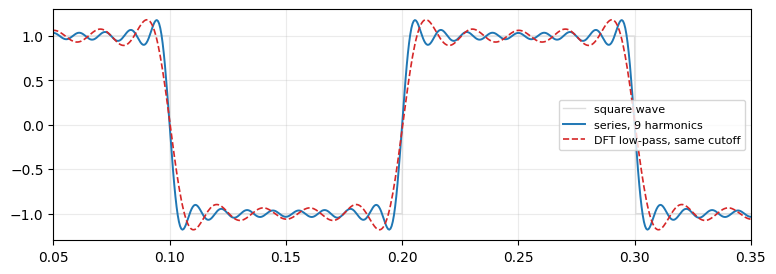

In [8]:
n_terms = 9
partial = signals.square_wave_partial_sum(t, F0, n_terms)
spec_lp = np.fft.rfft(x)
cutoff_hz = (n_terms + 1) * F0
spec_lp[np.fft.rfftfreq(x.size, 1 / FS) > cutoff_hz] = 0
lowpassed = np.fft.irfft(spec_lp, n=x.size)
print(f"max |series partial sum - DFT low-pass| = {np.max(np.abs(partial - lowpassed)):.4f}")
print(f"overshoot: series {(partial.max() - 1) * 100:5.2f} %"
      f"   DFT {(lowpassed.max() - 1) * 100:5.2f} %   (Gibbs limit 8.95 %)")

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t, x, color="#ddd", lw=1, label="square wave")
ax.plot(t, partial, lw=1.4, label=f"series, {n_terms} harmonics")
ax.plot(t, lowpassed, "--", color="#d62728", lw=1.2, label="DFT low-pass, same cutoff")
ax.set_xlim(0.05, 0.35); ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.show()

## 7. 割れるところ

### 7a. 観測長が周期の整数倍でないと DFT が漏れる

級数と変換は「無限に続く」前提を持つ。DFT は持たない。
観測窓が周期の整数倍でないとき、DFT は端の不連続を **信号の一部として** 読み、
本来無いはずの周波数にエネルギーを配る。

In [9]:
print(f"{'duration [s]':>13} {'periods':>9} {'leakage into non-harmonic bins':>32}")
for dur in [2.0, 2.05, 2.137]:
    tt = np.arange(0, dur, 1 / FS)
    xx = signals.square_wave(tt, F0)
    fr, am = transforms.amplitude_spectrum(xx, FS)
    harmonic = np.zeros(fr.size, dtype=bool)
    for n in range(1, 60, 2):
        harmonic |= np.abs(fr - n * F0) < (fr[1] - fr[0]) * 1.5
    inside = (fr > 0) & (fr < 150)
    leak = float(np.sum(am[inside & ~harmonic] ** 2) / np.sum(am[inside] ** 2))
    print(f"{dur:13.3f} {dur * F0:9.2f} {leak * 100:31.2f} %")
print("\n整数周期からずれるほど、非調和なビンへエネルギーが漏れる")

 duration [s]   periods   leakage into non-harmonic bins
        2.000     10.00                            0.05 %
        2.050     10.25                            6.57 %
        2.137     10.69                            8.55 %

整数周期からずれるほど、非調和なビンへエネルギーが漏れる


### 7b. 標本化が足りないと折り返す

矩形波は帯域無限(高調波が無限に続く)なので、**どんな $f_s$ でも標本化定理を満たせない**。
高調波が必ず折り返してくる。帯域制限は仮定であって、
実信号については確かめるべきことである。

In [10]:
print(f"{'fs [Hz]':>9} {'Nyquist':>9} {'harmonics below Nyquist':>25} "
      f"{'error vs 2000 Hz ref':>22}")
ref_t = np.arange(0, DURATION, 1 / 8000.0)
ref = signals.square_wave(ref_t, F0)
for fs_try in [2000.0, 200.0, 60.0, 30.0]:
    tt = np.arange(0, DURATION, 1 / fs_try)
    xx = signals.square_wave(tt, F0)
    n_harm = int((fs_try / 2) // F0)
    up = np.interp(ref_t, tt, xx)
    err = float(np.sqrt(np.mean((up - ref) ** 2)))
    print(f"{fs_try:9.0f} {fs_try / 2:9.0f} {n_harm:25d} {err:22.4f}")
print("\n矩形波は帯域無限なので、どの fs でもエイリアシングは残る")

  fs [Hz]   Nyquist   harmonics below Nyquist   error vs 2000 Hz ref
     2000      1000                       200                 0.0649
      200       100                        20                 0.2486
       60        30                         6                 0.4607
       30        15                         3                 0.6528

矩形波は帯域無限なので、どの fs でもエイリアシングは残る


### 7c. 3 者の「周波数」が指しているものは違う

同じ「50 Hz」でも意味が違う。

| 視点 | 50 Hz の意味 |
|---|---|
| 級数 | 第 10 倍音という **番号** |
| 変換 | 連続スペクトルの **1 点** |
| DFT | 幅 $\Delta f$ を持つ **ビン** |

DFT のビンは点ではなく区間なので、
「ピークがビン $k$ に立った」は「周波数が $k\Delta f$ ちょうど」を意味しない。
真の周波数がビンの間にあると、隣り合う 2 本に分かれる(この分割から補間で
真の周波数を推定するのが周波数補間の技法である)。

In [11]:
fs_i = 1000.0
n_i = 512
t_i = np.arange(n_i) / fs_i
df_i = fs_i / n_i
print(f"Δf = {df_i:.4f} Hz")
print(f"{'true f [Hz]':>13} {'top bin':>9} {'2nd bin':>9} {'ratio':>8} {'parabolic est.':>16}")
for f_true in [100.0, 100.5, 101.0]:
    sig_i = np.sin(2 * np.pi * f_true * t_i)
    sp = np.abs(np.fft.rfft(sig_i))
    k = int(np.argmax(sp))
    alpha, beta, gamma = sp[k - 1], sp[k], sp[k + 1]
    delta = 0.5 * (alpha - gamma) / (alpha - 2 * beta + gamma)
    nb = k - 1 if alpha > gamma else k + 1
    print(f"{f_true:13.2f} {k * df_i:9.2f} {nb * df_i:9.2f} "
          f"{min(alpha, gamma) / beta:8.3f} {(k + delta) * df_i:16.3f}")

Δf = 1.9531 Hz
  true f [Hz]   top bin   2nd bin    ratio   parabolic est.
       100.00     99.61    101.56    0.165           99.663
       100.50     99.61    101.56    0.315          100.203
       101.00    101.56     99.61    0.222          101.430


## 8. まとめ — どれを使うか

```{admonition} 3 つの視点の選び方
:class: tip
- **本当に周期的** で、係数そのものに意味があるなら **級数**(倍音構造・音色)
- **理論を導きたい** なら **変換**(畳み込み定理・微分・不確定性はここが一番きれい)
- **手元にデータがある** なら **DFT** 以外の選択肢は無い。ただし
  「有限長」「離散」という 2 つの仮定が、漏れとエイリアシングとして必ず現れる

3 者は同じ対象の違う近似であって、優劣ではない。
DFT の結果を読むときに級数と変換の言葉で考えられることが、この本の目的だった。
```

```{admonition} 姉妹本との接続
:class: note
- `analytics/linear_algebra` — DFT は正規直交基底への射影であり、DFT 行列はユニタリ行列である。
  基底変換としての見方はそちらが詳しい
- `analytics/laplace` — ラプラス変換は $s = \sigma + i\omega$ の複素平面に広げた版で、
  $\sigma = 0$ の虚軸上がフーリエ変換にあたる
- `analytics/differential_equation` — 08 章のスペクトル法は PDE 側から見ると
  固有関数展開そのものである
```

## Exercises

1. **三角波で同じことをする**: 本章の 3 視点を三角波で繰り返し、
   係数減衰が $1/n^2$ になること、Gibbs が出ないことを確かめよ。
2. **窓を変える**: 7a の漏れの実験で Hann 窓を掛けると漏れがどれだけ減るか測れ。
   減る代わりに何を失うか。
3. **帯域制限した矩形波**: 高調波を 15 次で打ち切った信号を作り、
   標本化定理を満たす $f_s$ を求め、7b の誤差が 0 に落ちることを確かめよ。
4. **周波数補間**: 7c の放物線補間の誤差を、真の周波数をビンの間で動かして測れ。
   どの位置で最も誤差が大きいか。
5. **逆問題**: DFT の振幅だけを保って位相をランダム化した信号を作り、
   波形がどう変わるかを見よ。位相が担っている情報は何か。